In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path

## Mind2Web-Live

In [ ]:
import re
from urllib.parse import urlparse

# regex specifically targeting: 'url': 'https://...'
url_pattern = re.compile(r"'url':\s*'(https?://[^']+)'")

def extract_first_base_url(eval_str):
    if pd.isna(eval_str):
        return None
    
    match = url_pattern.search(eval_str)
    if not match:
        return None
    
    parsed = urlparse(match.group(1))
    return f"{parsed.scheme}://{parsed.netloc}"



# train
mind_2_web_train = pd.read_csv('source/mind2web-live-train.csv')
mind_2_web_train["url"] = mind_2_web_train["evaluation"].apply(extract_first_base_url)
mind_2_web_train = mind_2_web_train[['index', 'task', 'url']]

# test
mind_2_web_test = pd.read_csv('source/mind2web-live-test.csv')
mind_2_web_test["url"] = mind_2_web_test["evaluation"].apply(extract_first_base_url)
mind_2_web_test = mind_2_web_test[['index', 'task', 'url']]

# mind_2_web_train = pd.read_csv('mind2web-live-train.csv')[['index', 'task']]
# mind_2_web_test = pd.read_csv('mind2web-live-test.csv')[['index', 'task']]

In [3]:
mind_2_web_train['source'] = 'mind_2_web_train'
mind_2_web_test['source'] = 'mind_2_web_test'

## WebVoyager

In [ ]:
with open('source/webVoyager_data.jsonl') as f:
    data = [json.loads(line) for line in f if line.strip()]
web_voyager_raw = pd.DataFrame(data)

In [5]:
web_voyager_raw

,web_name,id,ques,web
0,Allrecipes,Allrecipes--0,Provide a recipe for vegetarian lasagna with m...,https://www.allrecipes.com/
1,Allrecipes,Allrecipes--1,Find a recipe for a vegetarian lasagna that ha...,https://www.allrecipes.com/
2,Allrecipes,Allrecipes--2,Find a recipe for a vegetarian lasagna under 6...,https://www.allrecipes.com/
3,Allrecipes,Allrecipes--3,Locate a recipe for vegan chocolate chip cooki...,https://www.allrecipes.com/
4,Allrecipes,Allrecipes--4,Find a recipe for Baked Salmon that takes less...,https://www.allrecipes.com/
...,...,...,...,...
635,Wolfram Alpha,Wolfram Alpha--41,What is the approximate Heart Rate Reserve of ...,https://www.wolframalpha.com/
636,Wolfram Alpha,Wolfram Alpha--42,"What is the raw memory of a 100.2"" * 123.5"" tr...",https://www.wolframalpha.com/
637,Wolfram Alpha,Wolfram Alpha--43,A polyominoes of order 6 means you have 6 iden...,https://www.wolframalpha.com/
638,Wolfram Alpha,Wolfram Alpha--44,"Solve the ODE, g' + cos(g) = 0, if there is a ...",https://www.wolframalpha.com/


In [6]:
web_voyager_non_read_tasks_indices = ['Amazon--5', 'Amazon--15', 'Amazon--20', 'Booking--6', 'Booking--11', 'Booking--13', 'Booking--14',
                              'Google Flights--0', 'Google Flights--20', 'Google Map--13', 'Apple--9', 'Apple--17', 'Apple--22', 'Apple--32',
                              'GitHub--40', 'Google Search--15', 'ArXiv--41',
                              'Cambridge Dictionary--29', 'Cambridge Dictionary--38', 'Cambridge Dictionary--39',
                              'HuggingFace--1', 'HuggingFace--6', 'HuggingFace--10']
web_voyager = web_voyager_raw[web_voyager_raw['id'].isin(web_voyager_non_read_tasks_indices)]

In [7]:
web_voyager = web_voyager.rename(columns={'id': 'index', 'ques': 'task', 'web': 'url'})[['index', 'task', 'url']]
web_voyager['url'] = web_voyager['url'].str.rstrip('/')
web_voyager['source'] = 'web_voyager'

In [8]:
web_voyager

,index,task,url,source
50,Amazon--5,Find a Blue iPhone 12 Pro 128gb and add to cart.,https://www.amazon.com,web_voyager
60,Amazon--15,"Find a pair of mens running shoes in black, si...",https://www.amazon.com,web_voyager
65,Amazon--20,Search for a wireless ergonomic keyboard with ...,https://www.amazon.com,web_voyager
95,Apple--9,Check the Apple Store for the availability of ...,https://www.apple.com,web_voyager
103,Apple--17,Search Apple for the accessory Smart Folio for...,https://www.apple.com,web_voyager
108,Apple--22,Find out the trade-in value for an iPhone 13 P...,https://www.apple.com,web_voyager
118,Apple--32,Investigate the trade-in value for an iPhone 1...,https://www.apple.com,web_voyager
217,Booking--6,"Book one room which provides breakfast, and ai...",https://www.booking.com,web_voyager
222,Booking--11,Reserve a hotel in downtown Chicago with a rat...,https://www.booking.com,web_voyager
224,Booking--13,Find and book a hotel in Paris with suitable a...,https://www.booking.com,web_voyager


## BrowserComp

In [9]:
browser_comp_encrypted = pd.read_csv(
            "https://openaipublic.blob.core.windows.net/simple-evals/browse_comp_test_set.csv"
        )

In [10]:
import hashlib
import base64
def derive_key(password: str, length: int) -> bytes:
    """Derive a fixed-length key from the password using SHA256."""
    hasher = hashlib.sha256()
    hasher.update(password.encode())
    key = hasher.digest()
    return key * (length // len(key)) + key[: length % len(key)]


def decrypt(ciphertext_b64: str, password: str) -> str:
    """Decrypt base64-encoded ciphertext with XOR."""
    encrypted = base64.b64decode(ciphertext_b64)
    key = derive_key(password, len(encrypted))
    decrypted = bytes(a ^ b for a, b in zip(encrypted, key))
    return decrypted.decode()

browser_comp = pd.DataFrame([
    {
        "problem": decrypt(row["problem"], row["canary"]),
        "answer": decrypt(row["answer"], row["canary"]),
    }
    for _, row in browser_comp_encrypted.iterrows()
])

In [11]:
browser_comp.head(10)

,problem,answer
0,An African author tragically passed away in a ...,1988-96
1,"Between 1990 and 1994 (Inclusive), what teams ...",Ireland v Romania
2,"The player, born between 1981 and 1984, starte...",Amr Zaki
3,There is a Mexican restaurant in NM 2.5 to 3.5...,"Rosalea Murphy, 1912"
4,There was a global report released by the Worl...,Cristina Ortiz
5,"Between 1945 and 1955 inclusive, a particular ...",3:50 PM
6,The headquarters for a company widely reported...,Savannah College of Art and Design
7,Which 90s TV series starred an actor born in T...,Lush Life
8,What is the name of a movie that was released ...,White Mischief
9,The following details describe an individual: ...,"Mbem, Cameroon"


#### BrowserComp is a dataset for QAs that requires Web Search.

## VisualWebArena

In [12]:
vwa_classified_raw = pd.read_json('https://raw.githubusercontent.com/web-arena-x/visualwebarena/main/config_files/vwa/test_classifieds.raw.json')
vwa_classified = vwa_classified_raw[(vwa_classified_raw['require_login'] == True) & (~vwa_classified_raw['storage_state'].isna())]
vwa_classified = vwa_classified[['task_id', 'intent', 'start_url']].rename(columns={'task_id': 'index', 'intent': 'task', 'start_url': 'url'})
vwa_classified['source'] = 'vwa_classified'
# print("\n".join(vwa_classified.groupby('intent_template').groups.keys()))

In [13]:
vwa_shopping_raw = pd.read_json('https://raw.githubusercontent.com/web-arena-x/visualwebarena/main/config_files/vwa/test_shopping.raw.json')
vwa_shopping = vwa_shopping_raw[(vwa_shopping_raw['require_login'] == True) & (~vwa_shopping_raw['storage_state'].isna())]

print('\n'.join(vwa_shopping.groupby('intent_template').groups.keys()))

Add all the items I need to make this to my shopping cart.
Add all the items with {{quality}} on this page into my cart
Add something like the {{item}} to my shopping cart.
Add something like {{attribute}} to my wish list.
Add something like {{item}}, but {{attribute}}, from this page to my wish list.
Add the least expensive {{item}} that can hold {{storable}} to my shopping cart.
Add the product that {{attribute}} from my open tabs to the shopping cart
Add the {{attribute}} one in the {{order}} to my shopping cart.
Add the {{product}} in the {{location}} to my wish list.
Add the {{product}} to my wish list.
Add the {{product}} {{condition}} to my wish list.
Add this (in any size) to my cart if {{condition}}
Add this exact product to my shopping cart. I think it is in the "{{category}}" category.
Add this exact product to my wish list. I think it might be in the "{{category}}" category but I'm not certain.
Add this to my cart if {{condition}}
Add to my cart {{item}} {{condition}}.
Add 

In [14]:
vwa_reddit_raw = pd.read_json('https://raw.githubusercontent.com/web-arena-x/visualwebarena/main/config_files/vwa/test_reddit.raw.json')
vwa_reddit = vwa_reddit_raw[(vwa_reddit_raw['require_login'] == True) & (~vwa_reddit_raw['storage_state'].isna())]

print('\n'.join(vwa_reddit.groupby('intent_template').groups.keys()))

Can you comment '{{comment}}' on the post with {{item}} posted {{timeframe}}?
Can you comment '{{comment}}' on the top post (of all time) in {{forum}} that relates to the image?
Can you comment on the food from the country in the image and about {{description}} saying '{{comment}}'?
Can you find {{post}} and message the poster '{{message}}'?
Can you first make a post in {{forum1}} (then afterwards in {{forum2}}) asking for a comparison between the two {{item}} in the shopping tabs? Make sure to include both their SKUs in the title and a picture of the {{condition}}.
Can you help me find and navigate to the comments section of an image post that has something like this image?
Can you help me find and navigate to the comments section of the post with this image?
Can you make a post in f/food, title it '{{title}}', add the full sized version of the image with {{food}}, and navigate to it?
Can you make a post in {{forum}} titled '{{title}}', add the full sized version of the image on the s

## Aggregate the data

### Categorize

In [15]:
from urllib.parse import urlparse

def get_domain(u):
    if not u.startswith("http"):
        u = "https://" + u
    return urlparse(u).netloc.replace("www.", "")

def categorize(url, mapping):
    domain = get_domain(url)

    for k, urls in mapping.items():
        for u in urls:
            if get_domain(u) == domain:
                return k

    return "other"


In [16]:
web_voyager

,index,task,url,source
50,Amazon--5,Find a Blue iPhone 12 Pro 128gb and add to cart.,https://www.amazon.com,web_voyager
60,Amazon--15,"Find a pair of mens running shoes in black, si...",https://www.amazon.com,web_voyager
65,Amazon--20,Search for a wireless ergonomic keyboard with ...,https://www.amazon.com,web_voyager
95,Apple--9,Check the Apple Store for the availability of ...,https://www.apple.com,web_voyager
103,Apple--17,Search Apple for the accessory Smart Folio for...,https://www.apple.com,web_voyager
108,Apple--22,Find out the trade-in value for an iPhone 13 P...,https://www.apple.com,web_voyager
118,Apple--32,Investigate the trade-in value for an iPhone 1...,https://www.apple.com,web_voyager
217,Booking--6,"Book one room which provides breakfast, and ai...",https://www.booking.com,web_voyager
222,Booking--11,Reserve a hotel in downtown Chicago with a rat...,https://www.booking.com,web_voyager
224,Booking--13,Find and book a hotel in Paris with suitable a...,https://www.booking.com,web_voyager


In [17]:
mind_2_web_test

,index,task,url,source
0,3RLzqsxoItEoOZlm3dwjy,Add a e-gift card to bag of $100 for recipient...,https://www.underarmour.com,mind_2_web_test
1,Bvywj9SzJD5eYeZrtYY3m,Add the first wireless headphones to your cart...,https://www.amazon.com,mind_2_web_test
2,CPdTwa57mKJJiZPQg2542,Add formula 1 to my followed sports on foxsports,https://www.foxsports.com,mind_2_web_test
3,DAabNkqk7gX0dHEcC0sbd,"Find 32"" Curved monitor and add the third one ...",https://www.newegg.com,mind_2_web_test
4,FtCFJNz4WhhewmINgVRu5,Select a E-Gift card and add to cart with Best...,https://www.rei.com,mind_2_web_test
5,fuEsXYy-LGfFLHqNw9zWt,Add a front load washing machine under $800 to...,https://www.menards.com,mind_2_web_test
6,jfjr1xGSPsucAuuUEBwCR,Add to my wish list the highest rated activity...,https://www.viator.com,mind_2_web_test
7,p5Rh2uknkoIwgRqseo6wB,Find bluetooth vertical mouse with most review...,https://www.newegg.com,mind_2_web_test
8,QiIBNsu__PJ_wBbTxAzvf,Add a Swivel vacuum under $150 to my cart on m...,https://www.menards.com,mind_2_web_test
9,rG7Bw2NN2bQ7CRchbMrAq,Add The Wire to the watchlist on tvguide,https://www.tvguide.com,mind_2_web_test


In [18]:
mind_2_web_train

,index,task,url,source
0,aDUZsHGDATdWGluXuuoT1,Make a playlist and add 3 songs from popular S...,https://soundcloud.com,mind_2_web_train
1,3pgcXaIyKP86RuRIAYxuL,View the toddler collection and add one pair o...,https://www.uniqlo.com,mind_2_web_train
2,lH6Wm01-tqjwC26s_TCW_,Search and book the cheapest daytime only mont...,https://spothero.com,mind_2_web_train
3,Z4sN-x3Om-1ceaX-MGZOh,Add to my cart a women's T-shirt priced under ...,https://www.uniqlo.com,mind_2_web_train
4,U48JEskxYwDR2suJariKt,Schedule COVID-19 test appointment at 90028 in...,https://www.cvs.com,mind_2_web_train
5,ERwj-HJ1LyzPg78HDFLXl,Add a NBA basketball game for the PS5 to the s...,https://www.gamestop.com,mind_2_web_train
6,PXNnM5AIwCbqfP9xGvbGF,Trade in a Nemo Front Porch 2P Tent via mail w...,https://www.rei.com,mind_2_web_train
7,iqjHVXgRt7rDjJLy88EDX,Send a 50-dollar home sweet home gift to my fr...,https://www.menards.com,mind_2_web_train
8,4mvk0HOEdSNyXU_bN4t3t,Add a CVS brand covid home test kit to the car...,https://www.cvs.com,mind_2_web_train
9,NupriBvqw19uWKQKgcHRS,Shop for a Four Points by Sheraton gift card o...,https://www.marriott.com,mind_2_web_train


In [19]:
aggregated_dataset = pd.concat([mind_2_web_train, mind_2_web_test, web_voyager], ignore_index=True)

In [20]:
aggregated_dataset
# aggregated_dataset.to_csv('aggregated_dataset.csv', index=True)

,index,task,url,source
0,aDUZsHGDATdWGluXuuoT1,Make a playlist and add 3 songs from popular S...,https://soundcloud.com,mind_2_web_train
1,3pgcXaIyKP86RuRIAYxuL,View the toddler collection and add one pair o...,https://www.uniqlo.com,mind_2_web_train
2,lH6Wm01-tqjwC26s_TCW_,Search and book the cheapest daytime only mont...,https://spothero.com,mind_2_web_train
3,Z4sN-x3Om-1ceaX-MGZOh,Add to my cart a women's T-shirt priced under ...,https://www.uniqlo.com,mind_2_web_train
4,U48JEskxYwDR2suJariKt,Schedule COVID-19 test appointment at 90028 in...,https://www.cvs.com,mind_2_web_train
...,...,...,...,...
87,GitHub--40,Select Sign up on the GitHub homepage to see i...,https://github.com,web_voyager
88,Google Flights--0,Book a journey with return option on same day ...,https://www.google.com/travel/flights,web_voyager
89,Google Flights--20,Book a round-trip flight from San Francisco to...,https://www.google.com/travel/flights,web_voyager
90,Google Map--13,Find a parking lot in Gloucester and book a ri...,https://www.google.com/maps,web_voyager


In [21]:
# Unique urls in aggregated dataset
unique_urls = set(aggregated_dataset['url'].dropna().unique())
print(f"Total unique URLs in aggregated dataset: {len(unique_urls)}")

Total unique URLs in aggregated dataset: 42


In [22]:
app_categories_except_webbench = {
    "ecommerce_retail": [
        "https://www.amazon.com",
        "https://www.uniqlo.com",
        "https://www.cvs.com",
        "https://www.gamestop.com",
        "https://www.rei.com",
        "https://www.menards.com",
        "https://www.target.com",
        "https://www.ikea.com",
        "https://www.newegg.com",
        "https://www.kohls.com",
        "https://www.ebay.com",
        "https://www.underarmour.com",
        "https://www.underarmour.co.uk",
        "https://www.instacart.com",
        "https://www.discogs.com",
        "https://boardgamegeek.com",
        "https://www.apple.com",
        "https://arxiv.org"
    ],

    "travel_booking": [
        "https://www.booking.com",
        "https://www.google.com/travel/flights",
        "https://www.marriott.com",
        "https://www.viator.com",
        "https://www.thetrainline.com",
        "https://www.sixflags.com",
        "https://www.carnival.com"
    ],

    "parking_transport": [
        "https://spothero.com",
        "https://parking.com",
        "https://www.google.com/maps"
    ],

    "entertainment_media": [
        "https://soundcloud.com",
        "https://www.imdb.com",
        "https://www.tvguide.com",
        "https://store.steampowered.com",
        "https://steamcommunity.com",
        "https://www.ultimate-guitar.com",
        "https://www.last.fm",
        "https://www.foxsports.com"
    ],

    "health_pharmacy": [
        "https://www.cvs.com"
    ],

    "food_grocery": [
        "https://www.allrecipes.com",
        "https://www.instacart.com"
    ],

    "reference_education": [
        "https://dictionary.cambridge.org",
        "https://arxiv.org"
    ],

    "tech_platforms": [
        "https://github.com",
        "https://www.apple.com",
        "https://www.google.com"
    ],

    "automotive": [
        "https://www.carmax.com"
    ],

    "events_tickets": [
        "https://www.ticketcenter.com"
    ],

    "camping_membership": [
        "https://koa.com"
    ]
}
aggregated_dataset["category"] = aggregated_dataset["url"].apply(lambda x: categorize(x, app_categories_except_webbench))

In [23]:
app_categories_except_webbench

{'ecommerce_retail': ['https://www.amazon.com',
  'https://www.uniqlo.com',
  'https://www.cvs.com',
  'https://www.gamestop.com',
  'https://www.rei.com',
  'https://www.menards.com',
  'https://www.target.com',
  'https://www.ikea.com',
  'https://www.newegg.com',
  'https://www.kohls.com',
  'https://www.ebay.com',
  'https://www.underarmour.com',
  'https://www.underarmour.co.uk',
  'https://www.instacart.com',
  'https://www.discogs.com',
  'https://boardgamegeek.com',
  'https://www.apple.com',
  'https://arxiv.org'],
 'travel_booking': ['https://www.booking.com',
  'https://www.google.com/travel/flights',
  'https://www.marriott.com',
  'https://www.viator.com',
  'https://www.thetrainline.com',
  'https://www.sixflags.com',
  'https://www.carnival.com'],
 'parking_transport': ['https://spothero.com',
  'https://parking.com',
  'https://www.google.com/maps'],
 'entertainment_media': ['https://soundcloud.com',
  'https://www.imdb.com',
  'https://www.tvguide.com',
  'https://stor

In [24]:
aggregated_dataset

,index,task,url,source,category
0,aDUZsHGDATdWGluXuuoT1,Make a playlist and add 3 songs from popular S...,https://soundcloud.com,mind_2_web_train,entertainment_media
1,3pgcXaIyKP86RuRIAYxuL,View the toddler collection and add one pair o...,https://www.uniqlo.com,mind_2_web_train,ecommerce_retail
2,lH6Wm01-tqjwC26s_TCW_,Search and book the cheapest daytime only mont...,https://spothero.com,mind_2_web_train,parking_transport
3,Z4sN-x3Om-1ceaX-MGZOh,Add to my cart a women's T-shirt priced under ...,https://www.uniqlo.com,mind_2_web_train,ecommerce_retail
4,U48JEskxYwDR2suJariKt,Schedule COVID-19 test appointment at 90028 in...,https://www.cvs.com,mind_2_web_train,ecommerce_retail
...,...,...,...,...,...
87,GitHub--40,Select Sign up on the GitHub homepage to see i...,https://github.com,web_voyager,tech_platforms
88,Google Flights--0,Book a journey with return option on same day ...,https://www.google.com/travel/flights,web_voyager,travel_booking
89,Google Flights--20,Book a round-trip flight from San Francisco to...,https://www.google.com/travel/flights,web_voyager,travel_booking
90,Google Map--13,Find a parking lot in Gloucester and book a ri...,https://www.google.com/maps,web_voyager,travel_booking


In [25]:
len(aggregated_dataset)

92

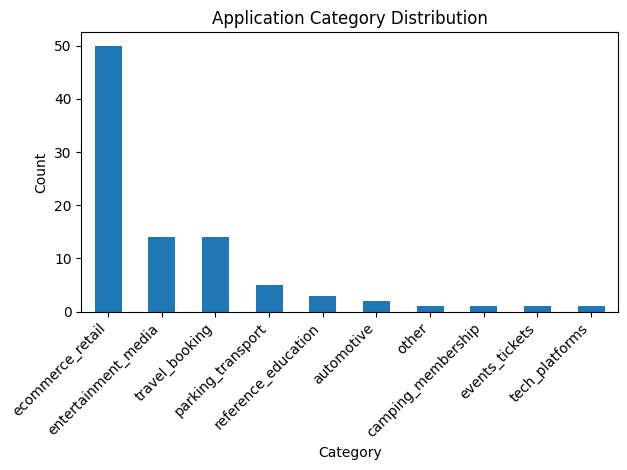

In [26]:
import matplotlib.pyplot as plt

counts = aggregated_dataset["category"].value_counts()

plt.figure()
counts.plot(kind="bar")
plt.title("Application Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## WebBench

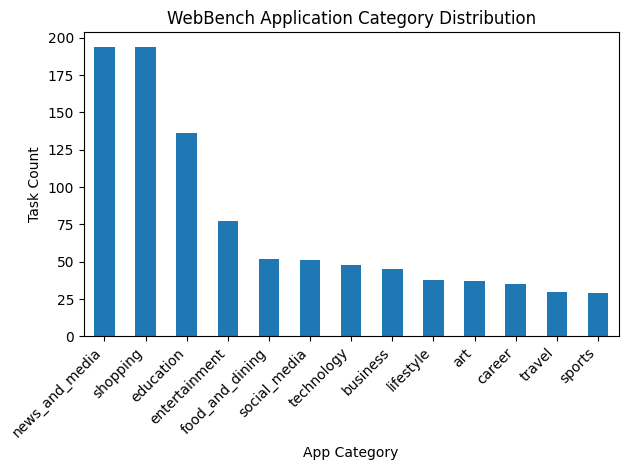

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path("./source/webbench")

dfs = []
app_categories_webbench = {}
for f in data_dir.glob("*.csv"):
    df = pd.read_csv(f)
    df = df[df["Category"] != "FILE_MANIPULATION"]
    df["AppCategory"] = f.stem  # filename → category
    dfs.append(df)

    # Record mapping from app categories to websites
    app_categories_webbench[f.stem] = df["Starting URL"].dropna().unique().tolist()

combined_webbench = pd.concat(dfs, ignore_index=True)

counts = combined_webbench["AppCategory"].value_counts()

plt.figure()
counts.plot(kind="bar")
plt.title("WebBench Application Category Distribution")
plt.xlabel("App Category")
plt.ylabel("Task Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [28]:
app_categories_webbench

{'art': ['https://www.deviantart.com',
  'https://flickr.com',
  'https://www.freepik.com',
  'https://www.istockphoto.com',
  'https://pixabay.com'],
 'food_and_dining': ['https://www.grubhub.com',
  'https://www.opentable.com',
  'https://restaurantguru.com',
  'https://resy.com',
  'https://www.doordash.com'],
 'career': ['https://www.glassdoor.com/index.htm', 'https://www.linkedin.com'],
 'education': ['https://www.apa.org',
  'https://www.jagranjosh.com',
  'https://www.khanacademy.org',
  'https://www.slideshare.net',
  'https://www.springer.com/us',
  'https://stackexchange.com',
  'https://stackoverflow.com/questions',
  'https://www.studocu.com',
  'https://www.wikidata.org/wiki/Wikidata:Main_Page',
  'https://www.wikihow.com/Main-Page',
  'https://www.wordhippo.com',
  'https://hinative.com',
  'https://www.answers.com'],
 'government': [],
 'social_media': ['https://www.facebook.com',
  'https://www.livejournal.com',
  'https://www.pinterest.com',
  'https://www.tiktok.com/e

In [29]:
num_urls = sum(len(urls) for urls in app_categories_webbench.values())
print(f"Total unique URLs in WebBench: {num_urls}")

Total unique URLs in WebBench: 111


# Merged Dataset

In [30]:
functional_taxonomy = {

    # 🛒 Transactional commerce systems
    # Buying, selling, checkout, subscriptions, orders.
    "transactional_commerce": [
        "https://www.amazon.com",
        "https://www.ebay.com",
        "https://www.walmart.com",
        "https://www.target.com",
        "https://www.ikea.com",
        "https://www.newegg.com",
        "https://www.bestbuy.com",
        "https://www.costco.com",
        "https://www.aliexpress.us",
        "https://us.shein.com",
        "https://www.uniqlo.com",
        "https://www.nike.com",
        "https://www.homedepot.com",
        "https://www.instacart.com",
        "https://www.gamestop.com",
        "https://www.rei.com",
        "https://www.kohls.com",
        "https://www.menards.com",
        "https://www.cvs.com",
        "https://www.underarmour.com",
        "https://www.underarmour.co.uk",
        "https://www.discogs.com",
        "https://boardgamegeek.com",
        "https://store.steampowered.com",
        "https://www.barnesandnoble.com",
        "https://www.dickssportinggoods.com",
        "https://www.nordstrom.com",
        "https://www.johnlewis.com",
        "https://www.redbubble.com",
        "https://www.playstation.com"
    ],

    # ✈️ Travel / booking / reservation systems
    "travel_booking": [
        "https://www.booking.com",
        "https://www.agoda.com",
        "https://www.airbnb.com",
        "https://www.expedia.com",
        "https://www.getyourguide.com",
        "https://www.marriott.com",
        "https://www.viator.com",
        "https://www.thetrainline.com",
        "https://www.sixflags.com",
        "https://www.carnival.com",
        "https://www.ticketcenter.com",
        "https://www.opentable.com",
        "https://resy.com"
    ],

    # 🗺 Navigation / mobility / geospatial systems
    "navigation_geospatial": [
        "https://www.google.com/maps",
        "https://rome2rio.com",
        "https://spothero.com",
        "https://parking.com",
        "https://www.alltrails.com"
    ],

    # 👥 Social/community interaction systems
    "social_community": [
        "https://www.facebook.com",
        "https://www.livejournal.com",
        "https://www.pinterest.com",
        "https://www.tiktok.com",
        "https://x.com"
    ],

    # 💬 Structured Q&A / discussion communities
    "knowledge_communities": [
        "https://stackexchange.com",
        "https://stackoverflow.com"
    ],

    # 🎬 Media consumption / streaming platforms
    "media_consumption": [
        "https://soundcloud.com",
        "https://open.spotify.com",
        "https://www.twitch.tv",
        "https://www.crunchyroll.com",
        "https://www.deezer.com",
        "https://letterboxd.com",
        "https://www.metacritic.com",
        "https://www.imdb.com",
        "https://www.tvguide.com",
        "https://www.ultimate-guitar.com",
        "https://www.last.fm",
        "https://www.foxsports.com"
    ],

    # 📰 Editorial journalism / publishing media
    "editorial_media": [
        "https://www.nytimes.com",
        "https://www.wired.com",
        "https://www.latimes.com",
        "https://www.telegraph.co.uk",
        "https://www.buzzfeed.com",
        "https://www.cnet.com",
        "https://www.caranddriver.com",
        "https://collider.com",
        "https://www.esquire.com",
        "https://gamerant.com",
        "https://www.gamesradar.com",
        "https://www.goodhousekeeping.com",
        "https://www.housebeautiful.com",
        "https://nypost.com",
        "https://www.pcgamer.com",
        "https://www.radiotimes.com",
        "https://www.thepioneerwoman.com",
        "https://www.today.com",
        "https://www.tomsguide.com",
        "https://www.usmagazine.com",
        "https://www.usnews.com",
        "https://medium.com",
        "https://www.countryliving.com",
        "https://www.express.co.uk",
        "https://www.vogue.com",
        "https://economictimes.indiatimes.com",
        "https://www.business-standard.com"
    ],

    # 📚 Knowledge / education / reference systems
    "knowledge_reference": [
        "https://arxiv.org",
        "https://dictionary.cambridge.org",
        "https://www.wikidata.org",
        "https://www.wikihow.com",
        "https://www.khanacademy.org",
        "https://www.springer.com",
        "https://www.wordhippo.com",
        "https://hinative.com",
        "https://www.answers.com",
        "https://www.apa.org",
        "https://www.jagranjosh.com",
        "https://www.studocu.com",
        "https://www.slideshare.net"
    ],

    # 💻 Developer collaboration platforms
    "developer_collaboration": [
        "https://github.com"
    ],

    # 🔎 Search / discovery infrastructure
    "search_engines": [
        "https://www.google.com",
        "https://www.bing.com"
    ],

    # 💼 Career / professional identity platforms
    "career_professional": [
        "https://www.glassdoor.com",
        "https://www.linkedin.com"
    ],

    # 🎨 Creative media asset sharing
    "creative_asset_sharing": [
        "https://www.deviantart.com",
        "https://flickr.com",
        "https://pixabay.com",
        "https://www.freepik.com",
        "https://www.istockphoto.com"
    ],

    # 🍽 Food delivery / dining services
    "food_services": [
        "https://www.grubhub.com",
        "https://restaurantguru.com",
        "https://www.doordash.com"
    ],

    # 🍳 Recipe / cooking content platforms
    "recipe_content": [
        "https://www.allrecipes.com",
        "https://www.delish.com",
        "https://www.simplyrecipes.com",
        "https://www.bbcgoodfood.com"
    ],

    # 💰 Financial data / markets / business intelligence
    "financial_data": [
        "https://www.crunchbase.com",
        "https://www.nasdaq.com",
        "https://www.bloomberg.com",
        "https://www.investing.com"
    ],

    # 🚗 Automotive services / marketplaces
    "automotive_services": [
        "https://www.carmax.com",
        "https://www.ford.com"
    ],

    # 🧭 Local directories / classified marketplaces
    "directory_marketplaces": [
        "https://www.yellowpages.com",
        "https://www.justdial.com",
        "https://newyork.craigslist.org",
        "https://streeteasy.com"
    ],

    # 🏕 Membership / subscription organizations
    "membership_services": [
        "https://koa.com"
    ],

    # 📦 Software distribution platforms
    "software_distribution": [
        "https://www.uptodown.com"
    ],

    # 🏅 Sports event tracking / stats platforms
    "sports_tracking": [
        "https://www.olympics.com",
        "https://www.sofascore.com",
        "https://www.sportskeeda.com"
    ]
}

In [31]:
aggregated_dataset["functional_category"] = aggregated_dataset["url"].apply(lambda x: categorize(x, functional_taxonomy))

combined_webbench["functional_category"] = combined_webbench["Starting URL"].apply(lambda x: categorize(x, functional_taxonomy))

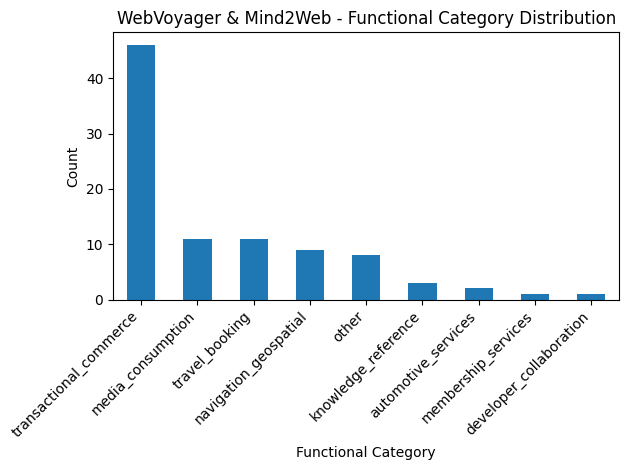

In [32]:
import matplotlib.pyplot as plt

counts_agg = aggregated_dataset["functional_category"].value_counts()

plt.figure()
counts_agg.plot(kind="bar")
plt.title("WebVoyager & Mind2Web - Functional Category Distribution")
plt.xlabel("Functional Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

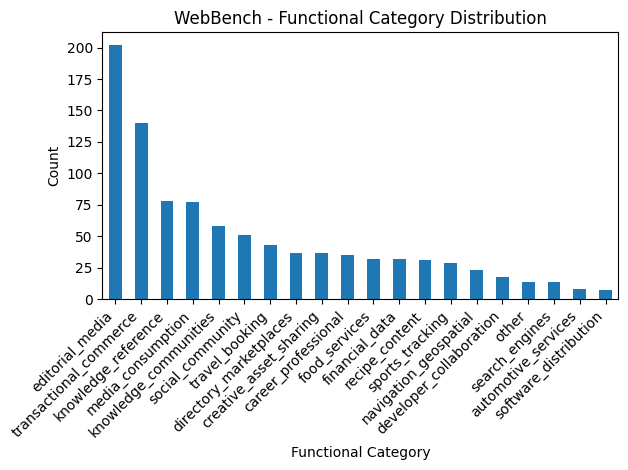

In [33]:
counts_webbench = combined_webbench["functional_category"].value_counts()

plt.figure()
counts_webbench.plot(kind="bar")
plt.title("WebBench - Functional Category Distribution")
plt.xlabel("Functional Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

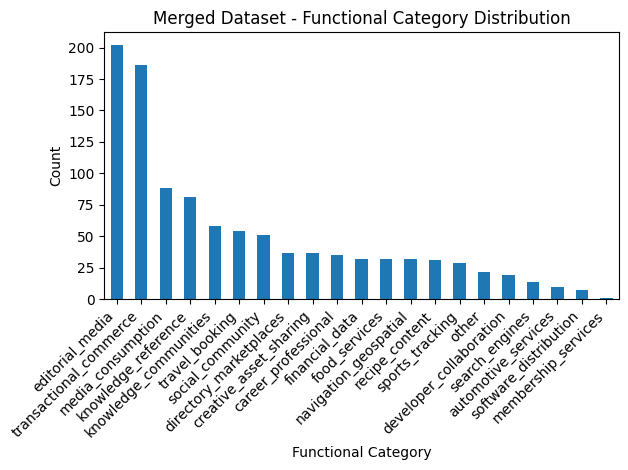

In [34]:
import pandas as pd

merged_series = pd.concat([
    aggregated_dataset["functional_category"],
    combined_webbench["functional_category"]
])

merged_counts = merged_series.value_counts()

plt.figure()
merged_counts.plot(kind="bar")
plt.title("Merged Dataset - Functional Category Distribution")
plt.xlabel("Functional Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [35]:
merged_series.size

1058

In [36]:
aggregated_dataset_processed = aggregated_dataset[['index', 'task', 'url', 'source', 'functional_category']]

In [37]:
combined_webbench_processed = combined_webbench.rename(columns={"ID": "index", "Task": "task", "Starting URL": "url", "AppCategory": "source"})[['index', 'task', 'url', 'source', 'functional_category']]
combined_webbench_processed["source"] = combined_webbench_processed["source"].apply(lambda x: f"webbench_{x}")

In [38]:
final_dataset = pd.concat([aggregated_dataset_processed, combined_webbench_processed], ignore_index=True)

## Analyze Capabilities

In [39]:
import os

APP_TYPE_TO_PROFILE = {
    "transactional_commerce": "commerce_platform",
    "directory_marketplaces": "commerce_platform",
    "food_services": "commerce_platform",
    "membership_services": "commerce_platform",

    "travel_booking": "reservation_service_platform",
    "automotive_services": "reservation_service_platform",

    "media_consumption": "media_library_platform",

    "creative_asset_sharing": "content_sharing_platform",
    "editorial_media": "content_sharing_platform",
    "recipe_content": "content_sharing_platform",

    "knowledge_communities": "knowledge_community_platform",
    "social_community": "knowledge_community_platform",

    "knowledge_reference": "information_reference_platform",
    "search_engines": "information_reference_platform",
    "financial_data": "information_reference_platform",
    "navigation_geospatial": "information_reference_platform",
    "other": "information_reference_platform",

    "developer_collaboration": "developer_collaboration_platform",
    "software_distribution": "developer_collaboration_platform",

    "career_professional": "professional_network_platform",
    "sports_tracking": "professional_network_platform"
}

final_dataset["profile"] = final_dataset["functional_category"].apply(lambda x: APP_TYPE_TO_PROFILE.get(x, "unknown"))

In [40]:
final_dataset.to_csv('data/final_dataset.csv', index=False)